In [5]:
import pandas as pd

# Load the dataset
df = pd.read_csv("sarcasm_dataset.csv")

# Display first few rows
print(df.head())

# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Dataset size
print(f"Dataset contains {df.shape[0]} samples and {df.shape[1]} columns.")


                                               tweet  target
0   That's how we roll😎 . . . . . . . . #cinemadd...       1
1                                       😂😂😂 #Sarcasm       1
2   At my bro Barbara school . I'm only one can i...       1
3   And I don’t know why people get hurt 😄 #sarca...       1
4   Yay. I see a #cold in my near #future 😂 #joke...       1
Missing values:
 tweet     0
target    0
dtype: int64
Dataset contains 16859 samples and 2 columns.


In [25]:
import re
import torch
from transformers import RobertaTokenizer, RobertaModel
from tqdm import tqdm  # For progress tracking

# Load RoBERTa tokenizer and model
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
model = RobertaModel.from_pretrained("roberta-base")

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def clean_text(text):
    """Preprocess text: remove URLs, convert to lowercase, remove special characters."""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|pic\.twitter\.com/\S+", "", text)  # Remove links
    text = re.sub(r"[^\w\s#@]", "", text)  # Remove special characters except hashtags and mentions
    return text

# Apply preprocessing
df["clean_text"] = df["tweet"].apply(clean_text)

# Function to process text in batches
def get_roberta_embeddings(text_list, batch_size=32):
    embeddings = []
    model.eval()
    
    for i in tqdm(range(0, len(text_list), batch_size), desc="Processing Batches"):
        batch_texts = text_list[i : i + batch_size]
        tokens = tokenizer(batch_texts, padding=True, truncation=True, return_tensors="pt").to(device)
        
        with torch.no_grad():
            outputs = model(**tokens).last_hidden_state[:, 0, :]  # Get CLS token embedding
            embeddings.append(outputs.cpu())  # Move to CPU to free GPU memory

    return torch.cat(embeddings, dim=0)

# Get text embeddings
text_embeddings = get_roberta_embeddings(df["clean_text"].tolist())

print("Preprocessing complete! Text embeddings shape:", text_embeddings.shape)


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Processing Batches: 100%|██████████| 527/527 [22:59<00:00,  2.62s/it]


Preprocessing complete! Text embeddings shape: torch.Size([16859, 768])


In [26]:
from transformers import AutoTokenizer, AutoModel

# Load Emoji-BERT tokenizer and model
emoji_tokenizer = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-emoji")
emoji_model = AutoModel.from_pretrained("cardiffnlp/twitter-roberta-base-emoji").to(device)

def extract_emojis(text):
    """Extract emojis from text."""
    emojis = re.findall(r"[^\w\s,]", text)  # Extract non-word characters (emojis)
    return "".join(emojis) if emojis else "[NO_EMOJI]"

# Apply emoji extraction
df["emojis"] = df["tweet"].apply(extract_emojis)

# Function to get emoji embeddings
def get_emoji_embeddings(emoji_list, batch_size=32):
    embeddings = []
    emoji_model.eval()

    for i in tqdm(range(0, len(emoji_list), batch_size), desc="Processing Emoji Batches"):
        batch_emojis = emoji_list[i : i + batch_size]
        tokens = emoji_tokenizer(batch_emojis, padding=True, truncation=True, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = emoji_model(**tokens).last_hidden_state[:, 0, :]
            embeddings.append(outputs.cpu())

    return torch.cat(embeddings, dim=0)

# Get emoji embeddings
emoji_embeddings = get_emoji_embeddings(df["emojis"].tolist())

print("Emoji processing complete! Emoji embeddings shape:", emoji_embeddings.shape)


Some weights of RobertaModel were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-emoji and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Processing Emoji Batches: 100%|██████████| 527/527 [08:42<00:00,  1.01it/s]

Emoji processing complete! Emoji embeddings shape: torch.Size([16859, 768])


In [62]:
import torch.nn.functional as F

# Normalize embeddings
text_embeddings = F.normalize(text_embeddings, p=2, dim=1)
emoji_embeddings = F.normalize(emoji_embeddings, p=2, dim=1)

# Concatenate text and emoji embeddings
combined_embeddings = torch.cat((text_embeddings, emoji_embeddings), dim=1)

print("Combined embeddings shape:", combined_embeddings.shape)  # Should be (16859, 1536)


Combined embeddings shape: torch.Size([16859, 1536])


In [69]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert labels to tensor
labels = torch.tensor(df["target"].values, dtype=torch.float32)

# Create dataset
dataset = TensorDataset(combined_embeddings, labels)

# Split into train (80%) and test (20%) sets
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define Model
class SarcasmModel(nn.Module):
    def __init__(self, input_dim):
        super(SarcasmModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

# Initialize model
model = SarcasmModel(input_dim=1536).to(device)

# Define loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training loop
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs).squeeze()
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss / len(train_loader):.4f}")

# Evaluation
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs).squeeze()
        predictions = (outputs > 0.5).float()  # Convert probabilities to binary (0 or 1)
        y_true.extend(targets.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\nModel Evaluation Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Epoch [1/5], Loss: 0.2376
Epoch [2/5], Loss: 0.0546
Epoch [3/5], Loss: 0.0386
Epoch [4/5], Loss: 0.0311
Epoch [5/5], Loss: 0.0266

Model Evaluation Results:
Accuracy: 0.9893
Precision: 0.9918
Recall: 0.9816
F1 Score: 0.9867


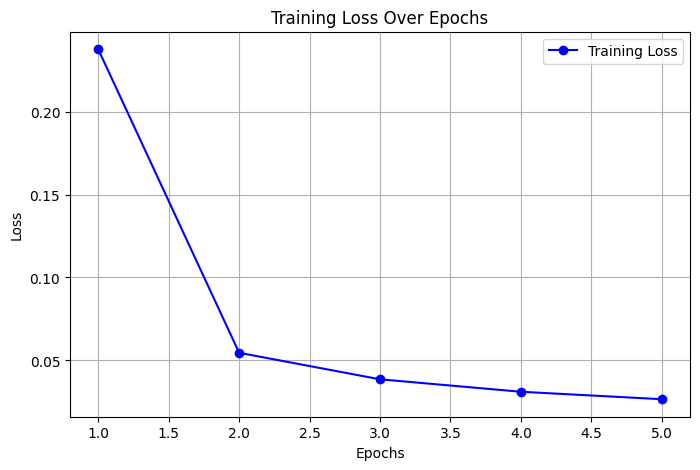

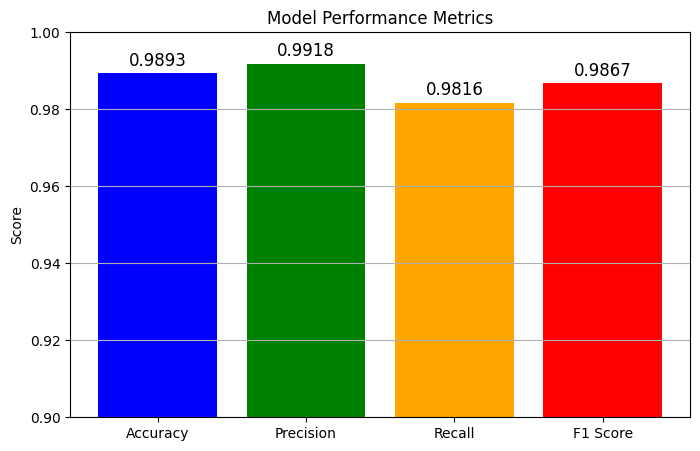

In [72]:
import matplotlib.pyplot as plt
import numpy as np

# Training Loss Graph
epochs = np.arange(1, 6)  # Since we trained for 5 epochs
loss_values = [0.2376, 0.0546, 0.0386, 0.0311, 0.0266]  # Loss from training

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss_values, marker='o', linestyle='-', color='b', label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.legend()
plt.grid()
plt.show()

# Model Performance Metrics Graph
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
values = [0.9893, 0.9918, 0.9816, 0.9867]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'green', 'orange', 'red'])
plt.ylim(0.9, 1.0)  # Adjusting scale for better visibility
plt.ylabel("Score")
plt.title("Model Performance Metrics")
plt.grid(axis='y')

# Display score on top of bars
for i, v in enumerate(values):
    plt.text(i, v + 0.002, str(round(v, 4)), ha='center', fontsize=12)

plt.show()


In [73]:
# Save the trained model
model_path = "sarcasm_detection_model.pth"
torch.save(model.state_dict(), model_path)

print(f"Model saved successfully at {model_path} ✅")


Model saved successfully at sarcasm_detection_model.pth ✅


In [74]:
# Load the model
loaded_model = SarcasmModel(input_dim=1536).to(device)
loaded_model.load_state_dict(torch.load("sarcasm_detection_model.pth"))
loaded_model.eval()  # Set to evaluation mode

print("Model loaded successfully! ✅ Ready for inference.")


Model loaded successfully! ✅ Ready for inference.
